In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, random_split
from transformers import ViTForImageClassification
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
from tqdm import tqdm
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# HOG+SVM transforms (no normalization - matches original implementation)
transform_hog = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# 64x64 transforms for Simple CNN (with normalization)
transform_train_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
transform_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 224x224 transforms for ResNet and ViT
transform_train_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Download datasets
train_hog_full = datasets.GTSRB(root='./data', split='train', transform=transform_hog, download=True)
train_full_64 = datasets.GTSRB(root='./data', split='train', transform=transform_train_64, download=False)
train_full_224 = datasets.GTSRB(root='./data', split='train', transform=transform_train_224, download=False)
test_hog = datasets.GTSRB(root='./data', split='test', transform=transform_hog, download=True)
test_64 = datasets.GTSRB(root='./data', split='test', transform=transform_64, download=True)
test_224 = datasets.GTSRB(root='./data', split='test', transform=transform_224, download=True)

# Same 90/10 split for all models
train_size = int(0.9 * len(train_hog_full))
val_size = len(train_hog_full) - train_size

train_hog, val_hog = random_split(train_hog_full, [train_size, val_size], generator=torch.Generator().manual_seed(42))
train_64, val_64 = random_split(train_full_64, [train_size, val_size], generator=torch.Generator().manual_seed(42))
train_224, val_224 = random_split(train_full_224, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# Loaders
train_loader_hog = DataLoader(train_hog, batch_size=64, shuffle=False, num_workers=2)
test_loader_hog = DataLoader(test_hog, batch_size=64, shuffle=False, num_workers=2)
train_loader_64 = DataLoader(train_64, batch_size=64, shuffle=True, num_workers=2)
val_loader_64 = DataLoader(val_64, batch_size=64, shuffle=False, num_workers=2)
test_loader_64 = DataLoader(test_64, batch_size=64, shuffle=False, num_workers=2)
train_loader_224 = DataLoader(train_224, batch_size=64, shuffle=True, num_workers=2)
val_loader_224 = DataLoader(val_224, batch_size=64, shuffle=False, num_workers=2)
test_loader_224 = DataLoader(test_224, batch_size=64, shuffle=False, num_workers=2)

print(f"Train: {len(train_hog)}, Val: {len(val_hog)}, Test: {len(test_hog)}")
print("All datasets ready!")

100%|██████████| 187M/187M [00:09<00:00, 19.1MB/s] 
100%|██████████| 89.0M/89.0M [00:04<00:00, 20.9MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 306kB/s]


Train: 23976, Val: 2664, Test: 12630
All datasets ready!


In [6]:
def apply_gaussian_blur(image, severity=1):
    kernel_sizes = [3, 5, 7, 9, 11]
    ksize = kernel_sizes[severity - 1]
    img_array = np.array(image)
    blurred = cv2.GaussianBlur(img_array, (ksize, ksize), 0)
    return Image.fromarray(blurred)

def apply_noise(image, severity=1):
    noise_levels = [5, 10, 20, 35, 50]
    noise_std = noise_levels[severity - 1]
    img_array = np.array(image).astype(np.float32)
    noise = np.random.normal(0, noise_std, img_array.shape)
    noisy = np.clip(img_array + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)

def apply_brightness(image, severity=1):
    brightness_factors = [0.8, 0.6, 0.4, 0.2, 0.1]
    factor = brightness_factors[severity - 1]
    img_array = np.array(image).astype(np.float32)
    darkened = np.clip(img_array * factor, 0, 255).astype(np.uint8)
    return Image.fromarray(darkened)

def apply_fog(image, severity=1):
    fog_intensities = [0.2, 0.35, 0.5, 0.65, 0.8]
    fog_intensity = fog_intensities[severity - 1]
    img_array = np.array(image).astype(np.float32)
    fog_layer = np.ones_like(img_array) * 255
    fogged = img_array * (1 - fog_intensity) + fog_layer * fog_intensity
    fogged = np.clip(fogged, 0, 255).astype(np.uint8)
    return Image.fromarray(fogged)

print("Degradation functions defined!")
print("Blur: severity 1-3")
print("Noise: severity 1-3")
print("Brightness: severity 1-4")
print("Fog: severity 1-4")

Degradation functions defined!
Blur: severity 1-3
Noise: severity 1-3
Brightness: severity 1-4
Fog: severity 1-4


In [7]:
# Extract HOG features - matching original implementation
def extract_hog_features(dataset):
    features = []
    labels = []
    for i in tqdm(range(len(dataset)), desc="Extracting HOG"):
        image, label = dataset[i]
        image_np = image.permute(1, 2, 0).numpy()
        hog_features = hog(
            image_np,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            channel_axis=-1
        )
        features.append(hog_features)
        labels.append(label)
    return np.array(features), np.array(labels)

print("Processing training set...")
X_train, y_train = extract_hog_features(train_hog)

print("Processing test set...")
X_test, y_test = extract_hog_features(test_hog)

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM
print("Training HOG+SVM...")
svm_model = LinearSVC(C=0.1, max_iter=2000, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_svm = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')
print(f"\nHOG+SVM Test Accuracy: {svm_accuracy * 100:.2f}%")
print(f"HOG+SVM Macro F1: {svm_f1:.4f}")

Processing training set...


Extracting HOG: 100%|██████████| 23976/23976 [00:51<00:00, 468.05it/s]


Processing test set...


Extracting HOG: 100%|██████████| 12630/12630 [00:26<00:00, 477.06it/s]


Training features shape: (23976, 1764)
Test features shape: (12630, 1764)
Training HOG+SVM...

HOG+SVM Test Accuracy: 87.17%
HOG+SVM Macro F1: 0.8555


In [8]:
# Simple CNN - matching original implementation (batch size 32)
train_loader_32 = DataLoader(train_64, batch_size=32, shuffle=True, num_workers=2)
val_loader_32 = DataLoader(val_64, batch_size=32, shuffle=False, num_workers=2)
test_loader_32 = DataLoader(test_64, batch_size=32, shuffle=False, num_workers=2)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 43)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model_cnn = SimpleCNN(num_classes=43).to(device)
print(f"Total parameters: {sum(p.numel() for p in model_cnn.parameters()):,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

best_val_acc = 0
for epoch in range(15):
    model_cnn.train()
    correct, total = 0, 0
    for images, labels in tqdm(train_loader_32, desc=f"Epoch {epoch+1}/15"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_acc = 100 * correct / total
    
    model_cnn.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_32:
            images, labels = images.to(device), labels.to(device)
            outputs = model_cnn(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    print(f"Epoch {epoch+1}: Train={train_acc:.2f}%, Val={val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_cnn.state_dict(), '/kaggle/working/cnn_best.pth')
    
    scheduler.step()

print(f"Best Val Accuracy: {best_val_acc:.2f}%")

# Test evaluation
model_cnn.eval()
all_preds_cnn, all_labels_cnn = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader_32, desc="Testing CNN"):
        images, labels = images.to(device), labels.to(device)
        outputs = model_cnn(images)
        _, predicted = outputs.max(1)
        all_preds_cnn.extend(predicted.cpu().numpy())
        all_labels_cnn.extend(labels.cpu().numpy())

cnn_accuracy = accuracy_score(all_labels_cnn, all_preds_cnn)
cnn_f1 = f1_score(all_labels_cnn, all_preds_cnn, average='macro')
print(f"\nSimple CNN Test Accuracy: {cnn_accuracy * 100:.2f}%")
print(f"Simple CNN Macro F1: {cnn_f1:.4f}")
torch.save(model_cnn.state_dict(), '/kaggle/working/cnn_final.pth')
print("Simple CNN saved!")

Total parameters: 2,201,707


Epoch 1/15: 100%|██████████| 750/750 [00:11<00:00, 64.36it/s]


Epoch 1: Train=43.59%, Val=76.28%


Epoch 2/15: 100%|██████████| 750/750 [00:10<00:00, 70.44it/s]


Epoch 2: Train=77.77%, Val=92.04%


...

Epoch 14: Train=98.71%, Val=99.74%


Epoch 15/15: 100%|██████████| 750/750 [00:10<00:00, 71.19it/s]


Epoch 15: Train=98.68%, Val=99.44%
Best Val Accuracy: 99.74%


Testing CNN: 100%|██████████| 395/395 [00:04<00:00, 93.28it/s] 


Simple CNN Test Accuracy: 93.65%
Simple CNN Macro F1: 0.8808
Simple CNN saved!


In [9]:
# ResNet18 - best configuration (4 epochs, no dropout, 224x224)
model_resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 43)
model_resnet = model_resnet.to(device)

criterion_r = nn.CrossEntropyLoss()
optimizer_r = torch.optim.Adam(model_resnet.parameters(), lr=0.0001)
scheduler_r = torch.optim.lr_scheduler.StepLR(optimizer_r, step_size=3, gamma=0.5)

best_val_acc_r = 0
for epoch in range(4):
    model_resnet.train()
    correct, total = 0, 0
    for images, labels in tqdm(train_loader_224, desc=f"Epoch {epoch+1}/4"):
        images, labels = images.to(device), labels.to(device)
        optimizer_r.zero_grad()
        outputs = model_resnet(images)
        loss = criterion_r(outputs, labels)
        loss.backward()
        optimizer_r.step()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_acc = 100 * correct / total
    
    model_resnet.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_224:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    print(f"Epoch {epoch+1}: Train={train_acc:.2f}%, Val={val_acc:.2f}%")
    
    if val_acc > best_val_acc_r:
        best_val_acc_r = val_acc
        torch.save(model_resnet.state_dict(), '/kaggle/working/resnet_best.pth')
        print(f"  → Best model saved!")
    
    scheduler_r.step()

print(f"\nBest Val Accuracy: {best_val_acc_r:.2f}%")

# Test evaluation
model_resnet.load_state_dict(torch.load('/kaggle/working/resnet_best.pth'))
model_resnet.eval()
all_preds_r, all_labels_r = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader_224, desc="Testing ResNet"):
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = outputs.max(1)
        all_preds_r.extend(predicted.cpu().numpy())
        all_labels_r.extend(labels.cpu().numpy())

resnet_accuracy = accuracy_score(all_labels_r, all_preds_r)
resnet_f1 = f1_score(all_labels_r, all_preds_r, average='macro')
print(f"\nResNet18 Test Accuracy: {resnet_accuracy * 100:.2f}%")
print(f"ResNet18 Macro F1: {resnet_f1:.4f}")
torch.save(model_resnet.state_dict(), '/kaggle/working/resnet_final.pth')
print("ResNet18 saved!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]
Epoch 1/4: 100%|██████████| 375/375 [01:24<00:00,  4.42it/s]


Epoch 1: Train=89.15%, Val=99.17%
  → Best model saved!


Epoch 2/4: 100%|██████████| 375/375 [01:24<00:00,  4.46it/s]


Epoch 2: Train=99.43%, Val=99.66%
  → Best model saved!


...

Epoch 3: Train=99.71%, Val=99.77%
  → Best model saved!


Epoch 4/4: 100%|██████████| 375/375 [01:23<00:00,  4.46it/s]


Epoch 4: Train=99.95%, Val=99.92%
  → Best model saved!

Best Val Accuracy: 99.92%


Testing ResNet: 100%|██████████| 198/198 [00:15<00:00, 13.04it/s]


ResNet18 Test Accuracy: 96.58%
ResNet18 Macro F1: 0.9206
ResNet18 saved!


In [10]:
# ViT - pretrained fine-tuning (2 epochs, matching original implementation)
model_vit = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=43,
    ignore_mismatched_sizes=True
)
model_vit = model_vit.to(device)
print(f"ViT loaded! Parameters: {sum(p.numel() for p in model_vit.parameters()):,}")

criterion_v = nn.CrossEntropyLoss()
optimizer_v = torch.optim.Adam(model_vit.parameters(), lr=0.0001)

best_val_acc_v = 0
for epoch in range(2):
    model_vit.train()
    correct, total = 0, 0
    for images, labels in tqdm(train_loader_224, desc=f"Epoch {epoch+1}/2"):
        images, labels = images.to(device), labels.to(device)
        optimizer_v.zero_grad()
        outputs = model_vit(images).logits
        loss = criterion_v(outputs, labels)
        loss.backward()
        optimizer_v.step()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_acc = 100 * correct / total
    
    model_vit.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_224:
            images, labels = images.to(device), labels.to(device)
            outputs = model_vit(images).logits
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    print(f"Epoch {epoch+1}: Train={train_acc:.2f}%, Val={val_acc:.2f}%")
    
    if val_acc > best_val_acc_v:
        best_val_acc_v = val_acc
        torch.save(model_vit.state_dict(), '/kaggle/working/vit_best.pth')
        print(f"  → Best model saved!")

print(f"\nBest Val Accuracy: {best_val_acc_v:.2f}%")

# Test evaluation
model_vit.load_state_dict(torch.load('/kaggle/working/vit_best.pth'))
model_vit.eval()
all_preds_v, all_labels_v = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader_224, desc="Testing ViT"):
        images, labels = images.to(device), labels.to(device)
        outputs = model_vit(images).logits
        _, predicted = outputs.max(1)
        all_preds_v.extend(predicted.cpu().numpy())
        all_labels_v.extend(labels.cpu().numpy())

vit_accuracy = accuracy_score(all_labels_v, all_preds_v)
vit_f1 = f1_score(all_labels_v, all_preds_v, average='macro')
print(f"\nViT Test Accuracy: {vit_accuracy * 100:.2f}%")
print(f"ViT Macro F1: {vit_f1:.4f}")
torch.save(model_vit.state_dict(), '/kaggle/working/vit_final.pth')
print("ViT saved!")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([43])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([43, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT loaded! Parameters: 85,831,723


...

Epoch 1: Train=91.85%, Val=99.29%
  → Best model saved!


Epoch 2/2: 100%|██████████| 375/375 [15:33<00:00,  2.49s/it]


Epoch 2: Train=99.38%, Val=98.76%

Best Val Accuracy: 99.29%


Testing ViT: 100%|██████████| 198/198 [02:58<00:00,  1.11it/s]



ViT Test Accuracy: 95.61%
ViT Macro F1: 0.9028
ViT saved!


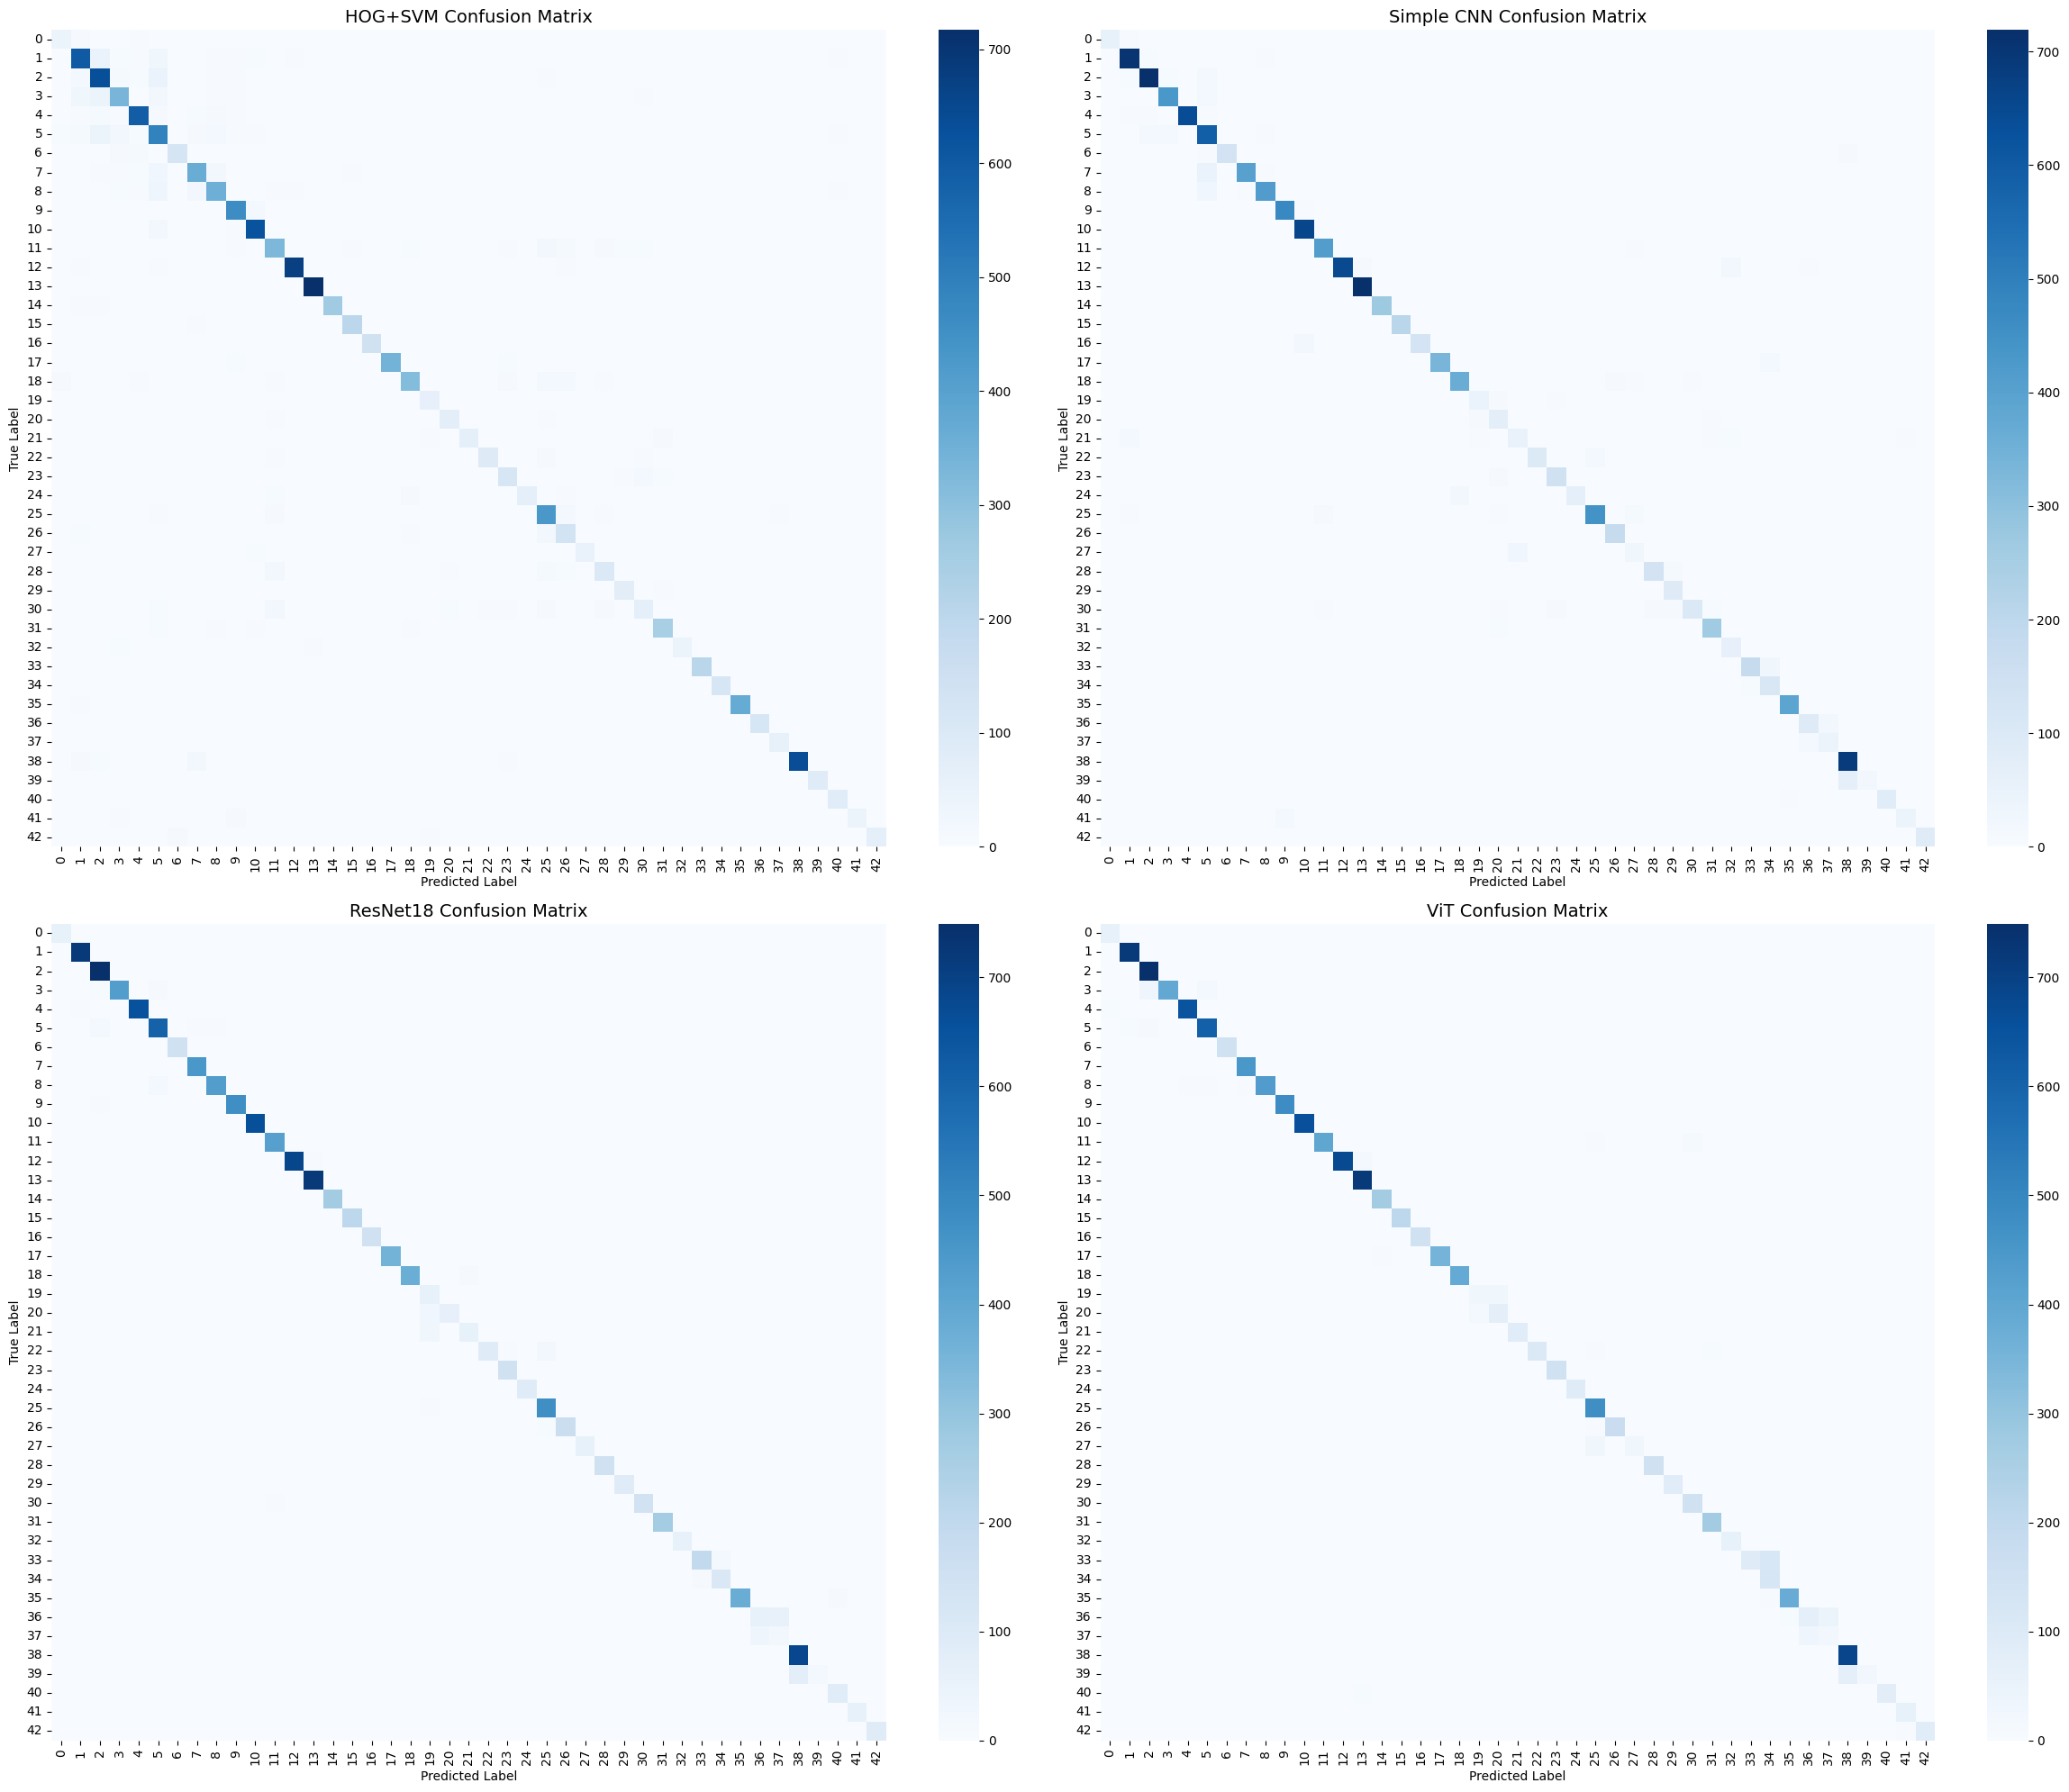

All confusion matrices saved!


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrices for all 4 models
class_names = [str(i) for i in range(43)]

fig, axes = plt.subplots(2, 2, figsize=(24, 20))

models_results = [
    ('HOG+SVM', y_test, y_pred_svm),
    ('Simple CNN', all_labels_cnn, all_preds_cnn),
    ('ResNet18', all_labels_r, all_preds_r),
    ('ViT', all_labels_v, all_preds_v)
]

for idx, (name, true, pred) in enumerate(models_results):
    ax = axes[idx//2][idx%2]
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name} Confusion Matrix', fontsize=14)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/kaggle/working/all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("All confusion matrices saved!")

In [12]:
# Robustness evaluation setup
# Test each model under different degradations and severities

from torchvision import transforms
import torch

# Normalize function for neural networks
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_degraded_loader(degradation_fn, severity, image_size=224, batch_size=64):
    """Create a dataloader with degraded images"""
    raw_test = datasets.GTSRB(root='./data', split='test', transform=None, download=False)
    
    degraded_images = []
    labels_list = []
    
    for i in range(len(raw_test)):
        img, label = raw_test[i]
        img_degraded = degradation_fn(img, severity)
        img_tensor = to_tensor(img_degraded)
        img_tensor = transforms.Resize((image_size, image_size))(img_tensor)
        img_tensor = normalize(img_tensor)
        degraded_images.append(img_tensor)
        labels_list.append(label)
    
    dataset = torch.utils.data.TensorDataset(
        torch.stack(degraded_images),
        torch.tensor(labels_list)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Robustness evaluation setup ready!")

Robustness evaluation setup ready!


In [13]:
def evaluate_model_on_loader(model, loader, model_type='cnn'):
    """Evaluate model accuracy on a dataloader"""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if model_type == 'vit':
                outputs = model(images).logits
            else:
                outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100 * correct / total

def evaluate_hog_on_loader(loader):
    """Evaluate HOG+SVM on degraded images"""
    all_preds, all_labels = [], []
    for images, labels in loader:
        images_np = images.numpy()
        for i in range(len(images_np)):
            img = images_np[i].transpose(1, 2, 0)
            feat = hog(img, orientations=9, pixels_per_cell=(8,8),
                      cells_per_block=(2,2), channel_axis=-1)
            all_preds.append(feat)
        all_labels.extend(labels.numpy())
    X = scaler.transform(np.array(all_preds))
    preds = svm_model.predict(X)
    return 100 * accuracy_score(all_labels, preds)

print("Evaluation functions defined!")

Evaluation functions defined!


In [14]:
# Robustness evaluation - test all models under all degradations
degradations = {
    'Gaussian Blur': (apply_gaussian_blur, [1, 2, 3]),
    'Noise': (apply_noise, [1, 2, 3]),
    'Low Brightness': (apply_brightness, [1, 2, 3, 4]),
    'Fog': (apply_fog, [1, 2, 3, 4])
}

results = {
    'HOG+SVM': {'clean': 87.17},
    'Simple CNN': {'clean': 93.65},
    'ResNet18': {'clean': 96.58},
    'ViT': {'clean': 95.61}
}

for deg_name, (deg_fn, severities) in degradations.items():
    print(f"\nEvaluating under {deg_name}...")
    for severity in severities:
        print(f"  Severity {severity}...")
        
        # Get degraded loader for HOG+SVM (64x64, no normalize)
        loader_hog = get_degraded_loader(deg_fn, severity, image_size=64, batch_size=64)
        # Get degraded loader for CNN (64x64)
        loader_64 = get_degraded_loader(deg_fn, severity, image_size=64, batch_size=64)
        # Get degraded loader for ResNet and ViT (224x224)
        loader_224 = get_degraded_loader(deg_fn, severity, image_size=224, batch_size=64)
        
        key = f"{deg_name}_S{severity}"
        
        # HOG+SVM
        hog_acc = evaluate_hog_on_loader(loader_hog)
        results['HOG+SVM'][key] = hog_acc
        
        # Simple CNN
        cnn_acc = evaluate_model_on_loader(model_cnn, loader_64, 'cnn')
        results['Simple CNN'][key] = cnn_acc
        
        # ResNet18
        resnet_acc = evaluate_model_on_loader(model_resnet, loader_224, 'cnn')
        results['ResNet18'][key] = resnet_acc
        
        # ViT
        vit_acc = evaluate_model_on_loader(model_vit, loader_224, 'vit')
        results['ViT'][key] = vit_acc
        
        print(f"    HOG+SVM={hog_acc:.2f}%, CNN={cnn_acc:.2f}%, ResNet={resnet_acc:.2f}%, ViT={vit_acc:.2f}%")

print("\nRobustness evaluation complete!")


Evaluating under Gaussian Blur...
  Severity 1...
    HOG+SVM=83.59%, CNN=91.34%, ResNet=93.67%, ViT=93.33%
  Severity 2...
    HOG+SVM=78.04%, CNN=87.77%, ResNet=88.59%, ViT=89.75%
  Severity 3...
    HOG+SVM=68.08%, CNN=80.50%, ResNet=79.00%, ViT=82.39%

Evaluating under Noise...
  Severity 1...
    HOG+SVM=78.18%, CNN=93.05%, ResNet=93.60%, ViT=94.41%
  Severity 2...
    HOG+SVM=63.77%, CNN=91.81%, ResNet=83.82%, ViT=89.74%
  Severity 3...
    HOG+SVM=45.15%, CNN=86.26%, ResNet=63.90%, ViT=77.44%

Evaluating under Low Brightness...
  Severity 1...
    HOG+SVM=86.56%, CNN=93.27%, ResNet=96.60%, ViT=95.76%
  Severity 2...
    HOG+SVM=86.80%, CNN=91.46%, ResNet=96.38%, ViT=95.99%
  Severity 3...
    HOG+SVM=86.82%, CNN=87.33%, ResNet=95.62%, ViT=93.95%
  Severity 4...
    HOG+SVM=86.56%, CNN=71.71%, ResNet=91.62%, ViT=80.89%

Evaluating under Fog...
  Severity 1...
    HOG+SVM=86.56%, CNN=91.05%, ResNet=95.48%, ViT=95.77%
  Severity 2...
    HOG+SVM=86.69%, CNN=85.06%, ResNet=93.16%, 

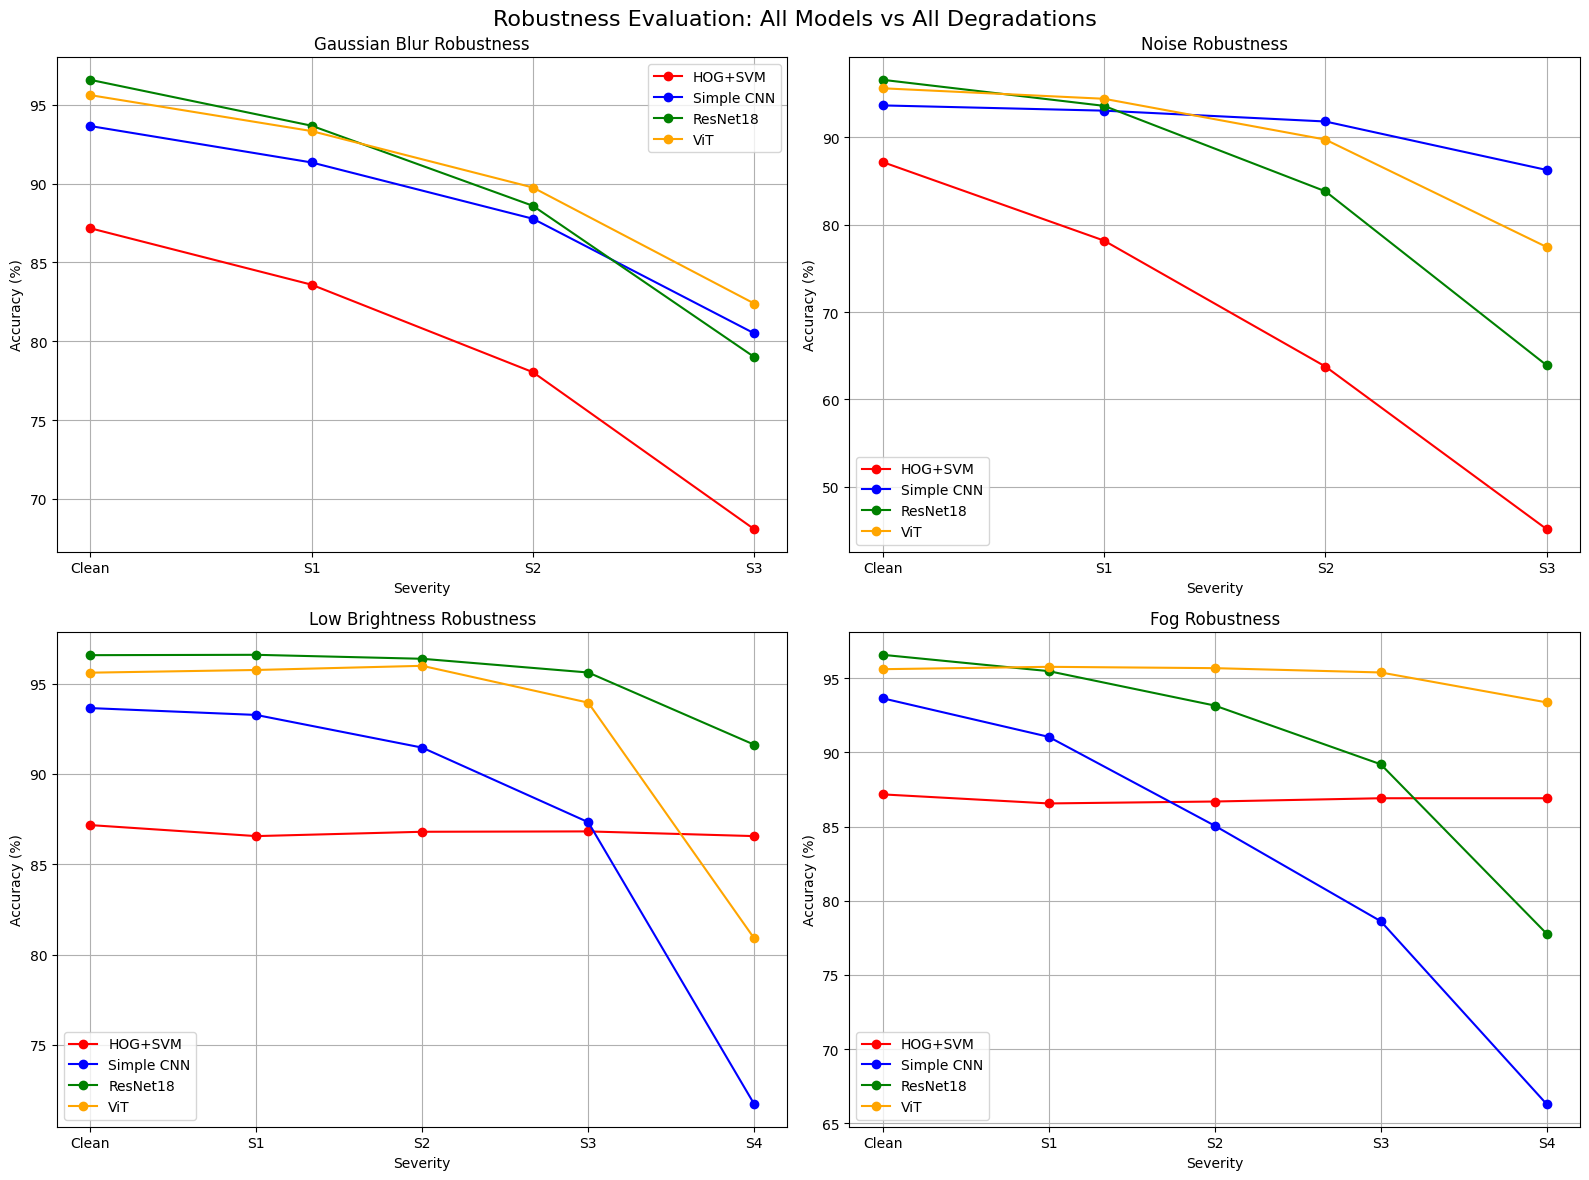

Robustness curves saved!


In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = ['HOG+SVM', 'Simple CNN', 'ResNet18', 'ViT']
colors = ['red', 'blue', 'green', 'orange']

# Blur
ax = axes[0][0]
blur_data = {
    'HOG+SVM': [87.17, 83.59, 78.04, 68.08],
    'Simple CNN': [93.65, 91.34, 87.77, 80.50],
    'ResNet18': [96.58, 93.67, 88.59, 79.00],
    'ViT': [95.61, 93.33, 89.75, 82.39]
}
for model, color in zip(models, colors):
    ax.plot([0,1,2,3], blur_data[model], marker='o', label=model, color=color)
ax.set_title('Gaussian Blur Robustness')
ax.set_xlabel('Severity')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['Clean', 'S1', 'S2', 'S3'])
ax.legend()
ax.grid(True)

# Noise
ax = axes[0][1]
noise_data = {
    'HOG+SVM': [87.17, 78.18, 63.77, 45.15],
    'Simple CNN': [93.65, 93.05, 91.81, 86.26],
    'ResNet18': [96.58, 93.60, 83.82, 63.90],
    'ViT': [95.61, 94.41, 89.74, 77.44]
}
for model, color in zip(models, colors):
    ax.plot([0,1,2,3], noise_data[model], marker='o', label=model, color=color)
ax.set_title('Noise Robustness')
ax.set_xlabel('Severity')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['Clean', 'S1', 'S2', 'S3'])
ax.legend()
ax.grid(True)

# Brightness
ax = axes[1][0]
brightness_data = {
    'HOG+SVM': [87.17, 86.56, 86.80, 86.82, 86.56],
    'Simple CNN': [93.65, 93.27, 91.46, 87.33, 71.71],
    'ResNet18': [96.58, 96.60, 96.38, 95.62, 91.62],
    'ViT': [95.61, 95.76, 95.99, 93.95, 80.89]
}
for model, color in zip(models, colors):
    ax.plot([0,1,2,3,4], brightness_data[model], marker='o', label=model, color=color)
ax.set_title('Low Brightness Robustness')
ax.set_xlabel('Severity')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks([0,1,2,3,4])
ax.set_xticklabels(['Clean', 'S1', 'S2', 'S3', 'S4'])
ax.legend()
ax.grid(True)

# Fog
ax = axes[1][1]
fog_data = {
    'HOG+SVM': [87.17, 86.56, 86.69, 86.91, 86.91],
    'Simple CNN': [93.65, 91.05, 85.06, 78.62, 66.28],
    'ResNet18': [96.58, 95.48, 93.16, 89.20, 77.77],
    'ViT': [95.61, 95.77, 95.68, 95.39, 93.37]
}
for model, color in zip(models, colors):
    ax.plot([0,1,2,3,4], fog_data[model], marker='o', label=model, color=color)
ax.set_title('Fog Robustness')
ax.set_xlabel('Severity')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks([0,1,2,3,4])
ax.set_xticklabels(['Clean', 'S1', 'S2', 'S3', 'S4'])
ax.legend()
ax.grid(True)

plt.suptitle('Robustness Evaluation: All Models vs All Degradations', fontsize=16)
plt.tight_layout()
plt.savefig('/kaggle/working/robustness_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Robustness curves saved!")

In [17]:
# Print complete robustness summary table
print("="*70)
print("COMPLETE ROBUSTNESS EVALUATION SUMMARY")
print("="*70)
print(f"\n{'Degradation':<20} {'Severity':<10} {'HOG+SVM':<12} {'CNN':<12} {'ResNet':<12} {'ViT':<12}")
print("-"*70)

all_results = {
    'Blur':       {'S1': [83.59, 91.34, 93.67, 93.33],
                   'S2': [78.04, 87.77, 88.59, 89.75],
                   'S3': [68.08, 80.50, 79.00, 82.39]},
    'Noise':      {'S1': [78.18, 93.05, 93.60, 94.41],
                   'S2': [63.77, 91.81, 83.82, 89.74],
                   'S3': [45.15, 86.26, 63.90, 77.44]},
    'Brightness': {'S1': [86.56, 93.27, 96.60, 95.76],
                   'S2': [86.80, 91.46, 96.38, 95.99],
                   'S3': [86.82, 87.33, 95.62, 93.95],
                   'S4': [86.56, 71.71, 91.62, 80.89]},
    'Fog':        {'S1': [86.56, 91.05, 95.48, 95.77],
                   'S2': [86.69, 85.06, 93.16, 95.68],
                   'S3': [86.91, 78.62, 89.20, 95.39],
                   'S4': [86.91, 66.28, 77.77, 93.37]}
}

for deg, severities in all_results.items():
    for sev, vals in severities.items():
        print(f"{deg:<20} {sev:<10} {vals[0]:<12.2f} {vals[1]:<12.2f} {vals[2]:<12.2f} {vals[3]:<12.2f}")
    print()

print("="*70)
print("\nKEY FINDINGS:")
print("1. ViT most robust under Blur and Fog")
print("2. Simple CNN most robust under Noise")
print("3. ResNet most robust under Brightness")
print("4. HOG+SVM most sensitive to Noise, robust to Brightness")
print("5. All deep models significantly outperform HOG+SVM under noise")

COMPLETE ROBUSTNESS EVALUATION SUMMARY

Degradation          Severity   HOG+SVM      CNN          ResNet       ViT         
----------------------------------------------------------------------
Blur                 S1         83.59        91.34        93.67        93.33       
Blur                 S2         78.04        87.77        88.59        89.75       
Blur                 S3         68.08        80.50        79.00        82.39       

Noise                S1         78.18        93.05        93.60        94.41       
Noise                S2         63.77        91.81        83.82        89.74       
Noise                S3         45.15        86.26        63.90        77.44       

Brightness           S1         86.56        93.27        96.60        95.76       
Brightness           S2         86.80        91.46        96.38        95.99       
Brightness           S3         86.82        87.33        95.62        93.95       
Brightness           S4         86.56        71